In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data amount: full vs full-80B

Memorization comparison: isolates the effect of pretraining token budget (40B vs 80B FineWeb-Edu filler).
Reads `mem-results/SparseGutenberg`.

In [ ]:
import os
import sys

PDM_DIR = os.environ.get('PDM_DIR', '../../../../PDM')
sys.path.append(f'{PDM_DIR}/src')
import verbatim_eval.controlled_expr as _ce
import verbatim_eval.rouge_ttr as _rt
import verbatim_eval.utils as _ut
sys.modules['controlled_expr'] = _ce  # needed for pickle deserialization
sys.modules['rouge_ttr'] = _rt
sys.modules['utils'] = _ut

sys.path.insert(0, '../../..')
from attn_bench.plotting import model_registry
from attn_bench.plotting.data_loading import load_mem_results_scores_grid
from attn_bench.plotting.heatmap import plot_models_heatmap, plot_models_heatmap_panel

## Old (mismatched) sweep

full-80B-scf8 (current, correct generation) only has a single reference point. full-80B-scf8-scf1 (the RoPE-scaling-mismatched, archived generation) has the full offset/prefix sweep, paired here with full-scf8-scf1 (same old generation) -- internally consistent, but this is the old, known-buggy data, not the current-correct one.

In [32]:
OLD_MODELS = ['full-scf8-scf1', 'full-80B-scf8-scf1']

OFFSETS = [0, 1, 5, 12, 25, 50, 100, 500, 1000, 2000]
PREFIXES = [50, 100, 250, 500, 750, 1000, 2000, 3000]
SUFFIXES = [50, 500]

old_results_grid = load_mem_results_scores_grid(
    OFFSETS, PREFIXES, SUFFIXES, models=OLD_MODELS, results_base=model_registry.MEM_RESULTS_DIR
)

### Offsets

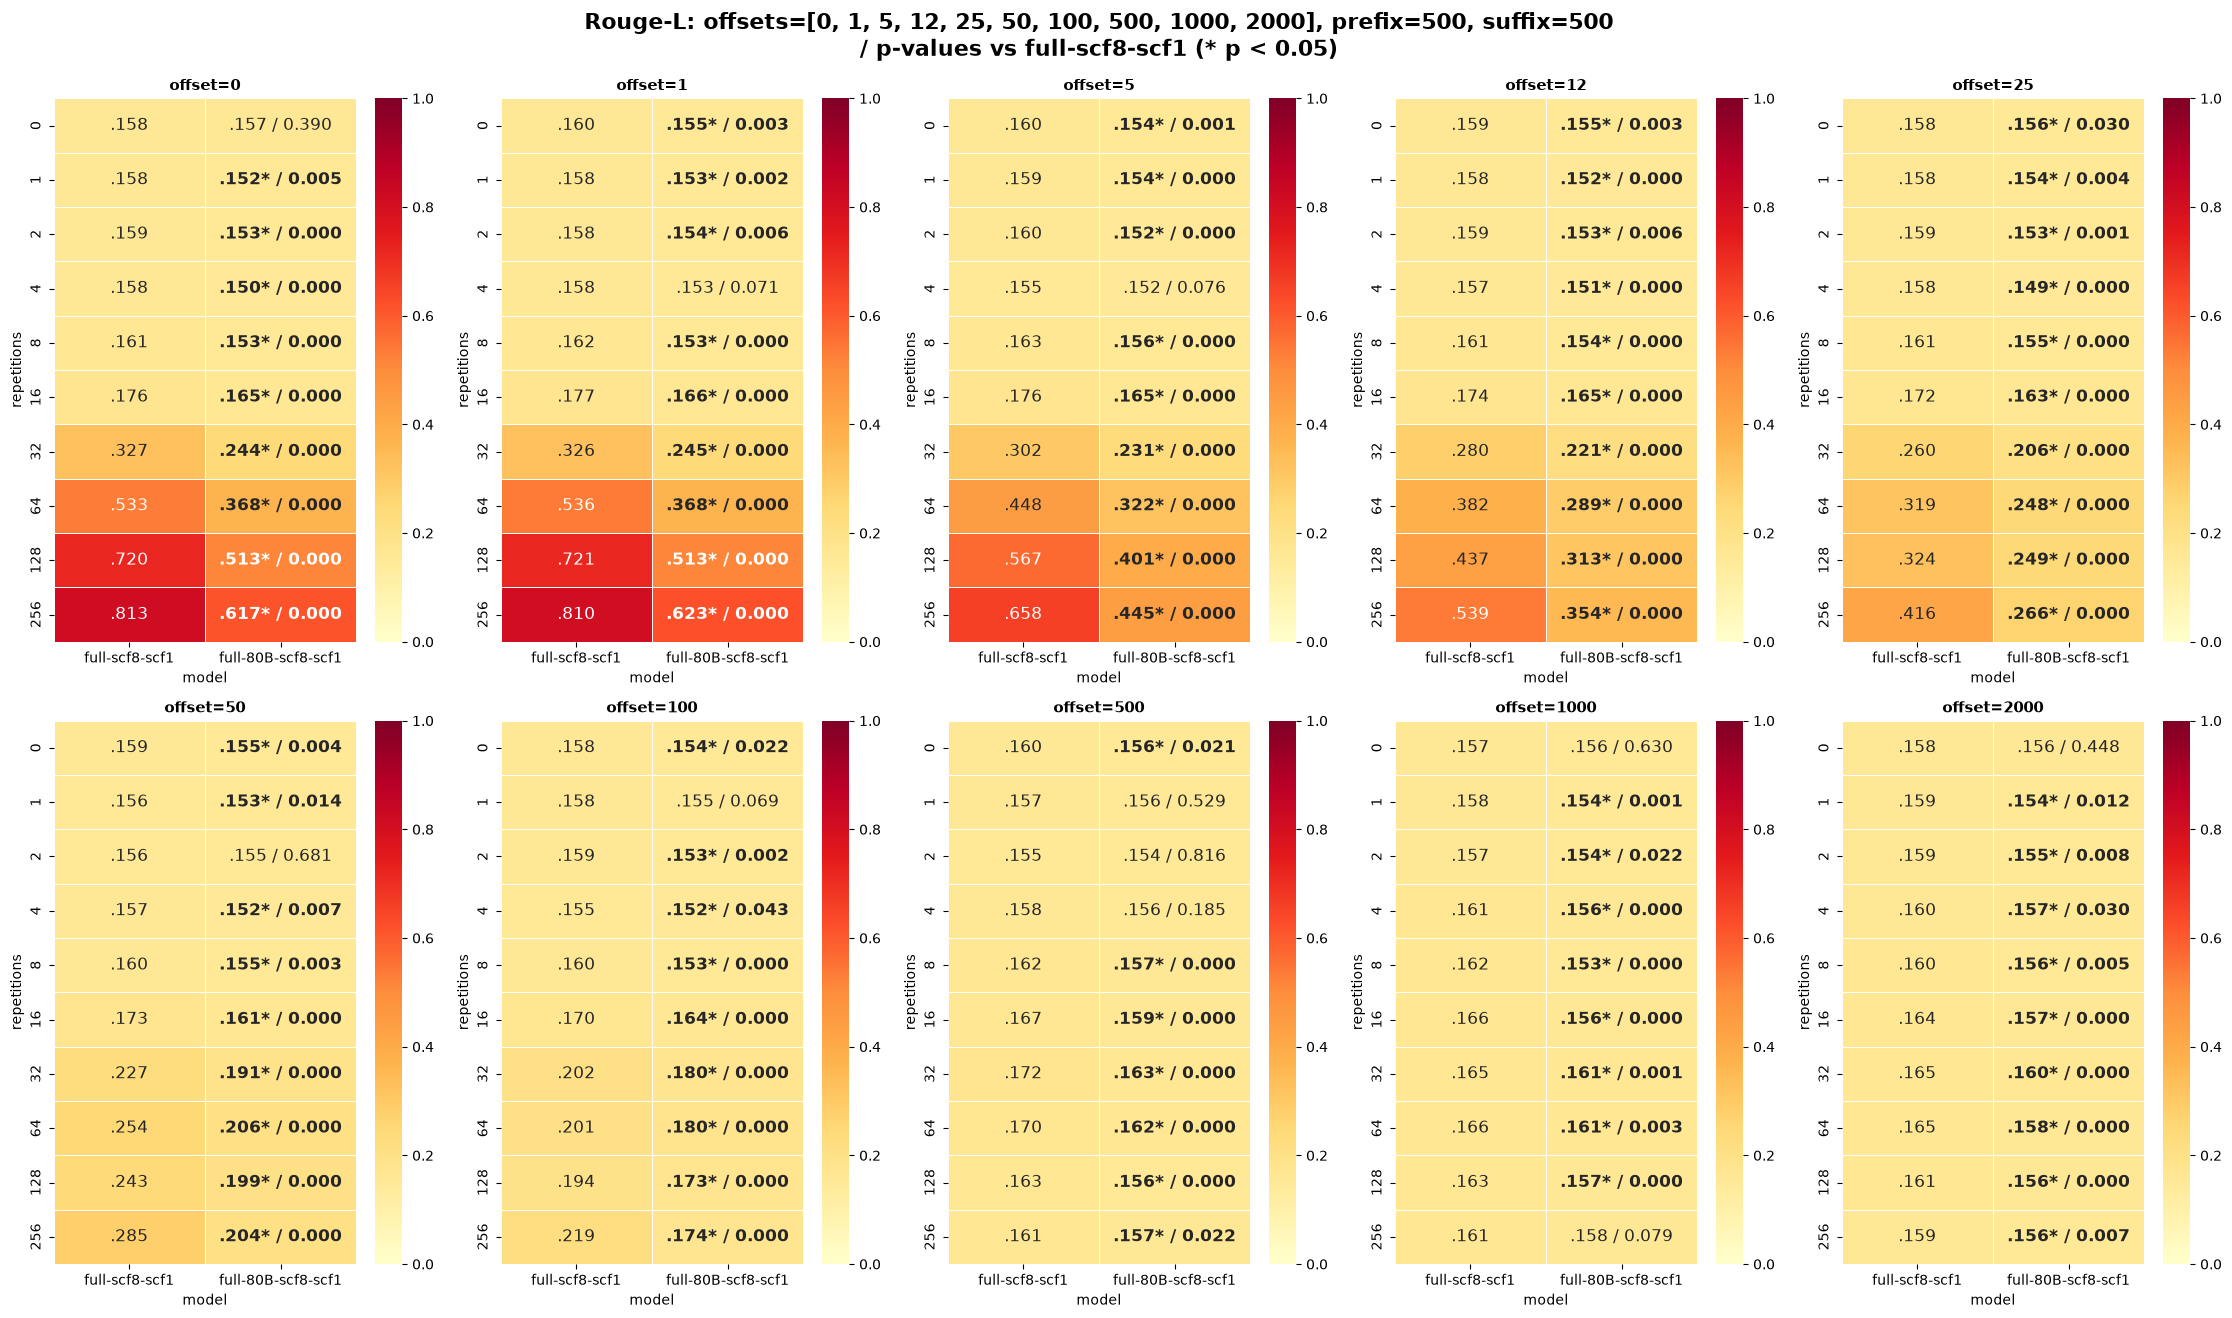

In [33]:
plot_models_heatmap_panel(
    old_results_grid, 'Rouge-L', models=OLD_MODELS, panels='offset', values=OFFSETS, fixed_prefix=500, fixed_suffix=500, ncols=5,
    reference='full-scf8-scf1',
)

### Prefixes

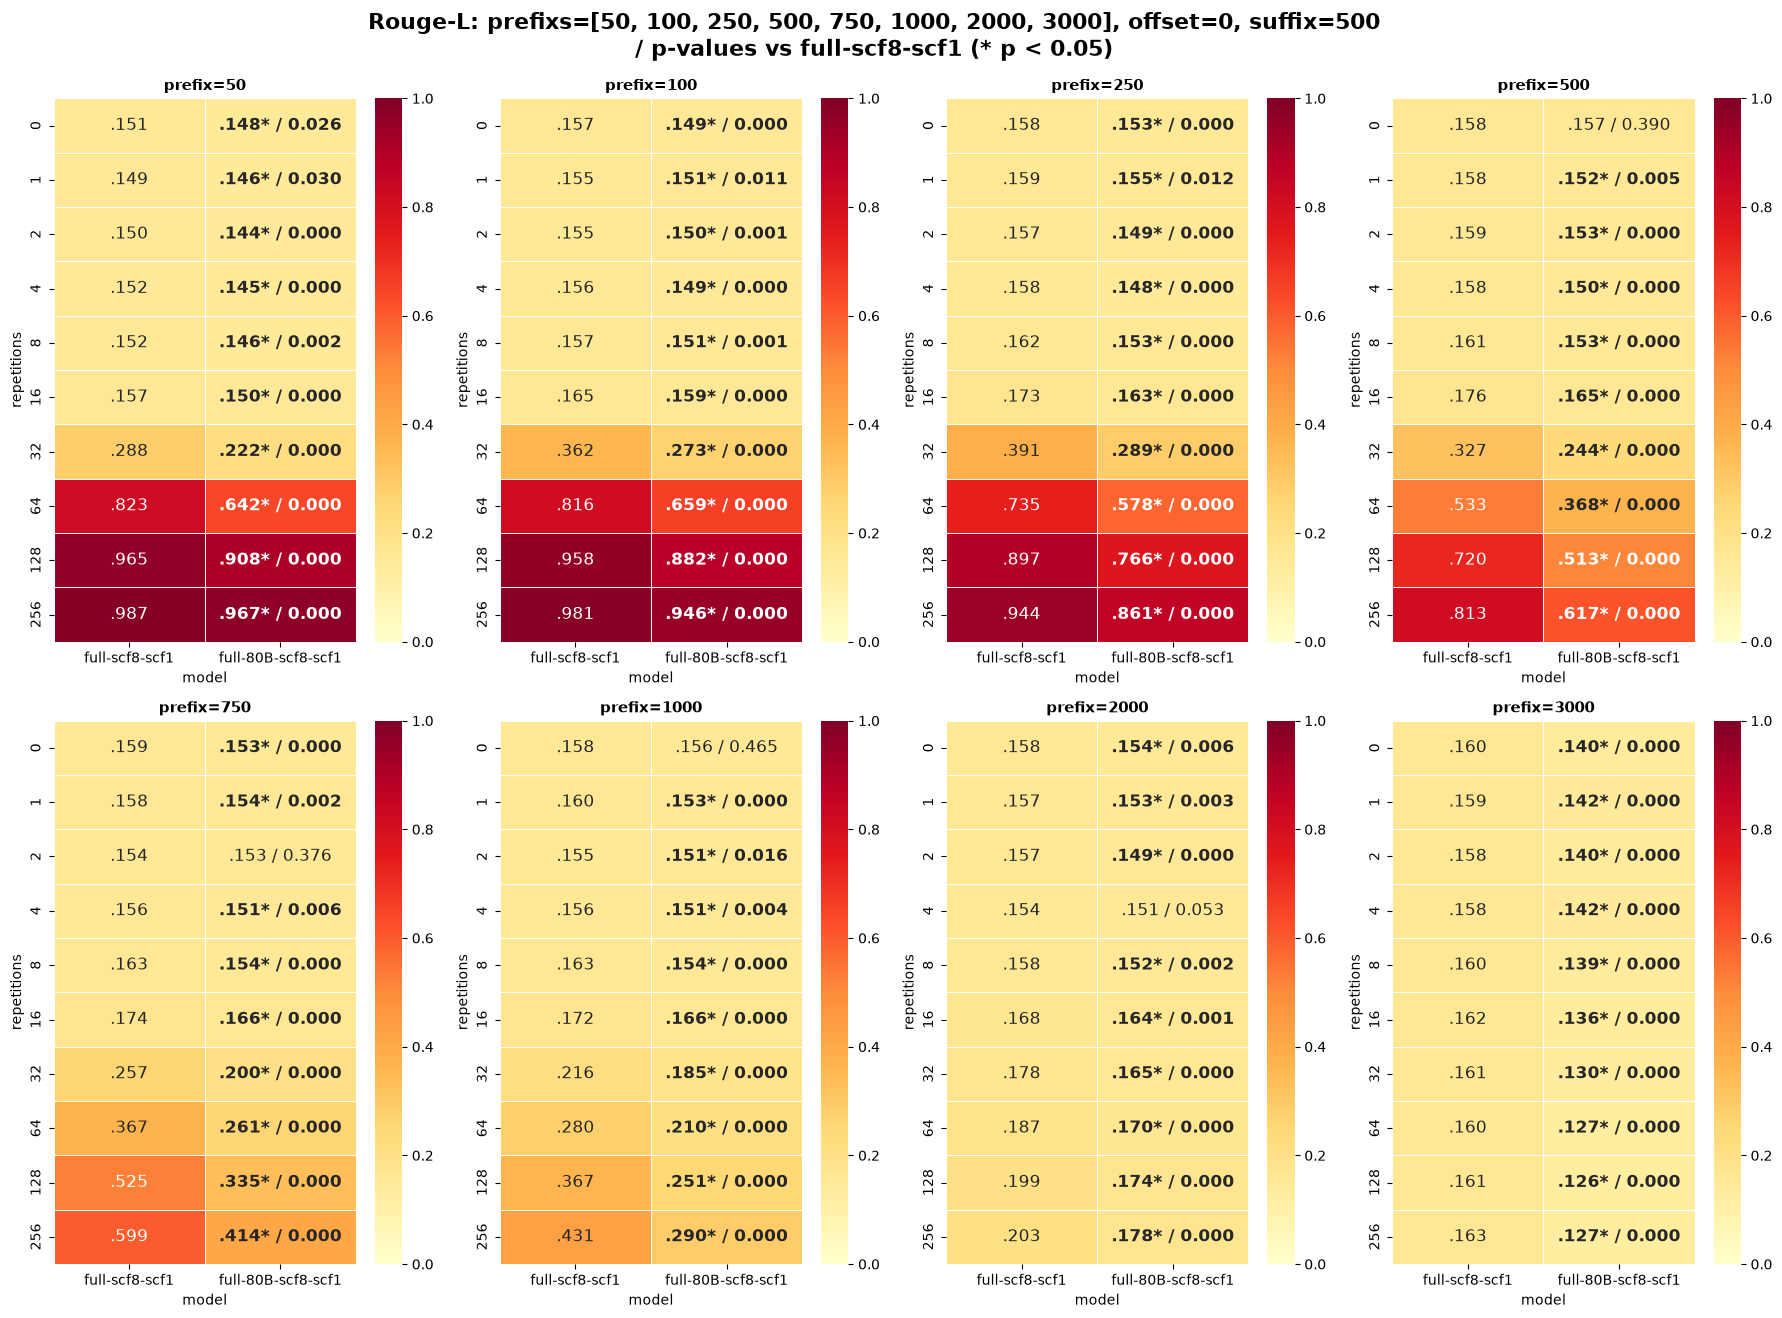

In [34]:
plot_models_heatmap_panel(
    old_results_grid, 'Rouge-L', models=OLD_MODELS, panels='prefix', values=PREFIXES, fixed_offset=0, fixed_suffix=500, ncols=4,
    reference='full-scf8-scf1',
)

## Corrected scf8

## Load memorization results

In [39]:
MODELS = ['full-scf8', 'full-80B-scf8']

OFFSETS = [0, 1, 5, 12, 25, 50, 100, 500, 1000, 2000]
PREFIXES = [50, 100, 250, 500, 750, 1000, 2000, 3000]
SUFFIXES = [50, 500]

results_grid = load_mem_results_scores_grid(
    OFFSETS, PREFIXES, SUFFIXES, models=MODELS, results_base=model_registry.MEM_RESULTS_DIR
)

## Rouge-L
full-80B-scf8 only has one captured point (offset=0, prefix=500, suffix=500) -- a single heatmap, not a swept panel, since that's all there is to show.

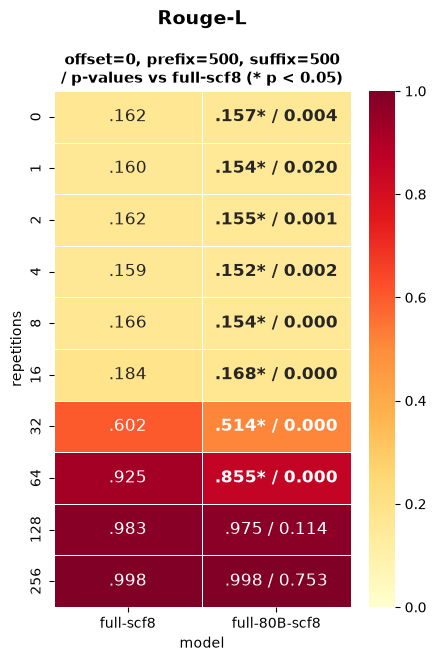

In [43]:
entry = results_grid[(0, 500, 500)]
plot_models_heatmap(entry, 'Rouge-L', offset=0, prefix=500, suffix=500, models=MODELS, reference='full-scf8')